# 05. Metrics

В этом notebook мы аккуратно разбираем базовые top-K метрики для рекомендательных систем и применяем их к моделям, которые уже построили в core-маршруте.

## Что изучим

- почему обычная `accuracy` почти не подходит для recommender systems;
- как считаются `Precision@K`, `Recall@K`, `HitRate@K`, `MAP@K`, `NDCG@K`;
- как проверить формулы на tiny fixture с известным ответом;
- как считать метрики на реальных рекомендациях;
- почему сравнение с baseline обязательно и как интерпретировать метрики без самообмана.


## Интуиция

В рекомендациях нас обычно интересует не точность по всем парам `user-item`, а то, насколько хорош список top-K рекомендаций.

Это важно по двум причинам:

- user-item пространство очень разрежено;
- на практике пользователь видит только короткий список рекомендаций, а не весь каталог.

Поэтому и метрики здесь должны отвечать на вопрос: насколько полезны первые несколько рекомендаций.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src" / "recsys_basics").exists():
            return candidate
    raise FileNotFoundError("Не удалось найти корень проекта с папкой src/recsys_basics")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("ggplot")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")


PROJECT_ROOT: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero


In [2]:
from recsys_basics.basic.item_item import ItemBasedCollaborativeRecommender
from recsys_basics.basic.popularity import (
    PopularityRecommender,
    build_seen_items_map,
    filter_positive_explicit_feedback,
)
from recsys_basics.data import build_explicit_interactions, get_movielens_data_dir, load_movielens_frames
from recsys_basics.metrics import (
    average_precision_at_k,
    evaluate_ranking_metrics,
    hit_rate_at_k,
    ndcg_at_k,
    precision_at_k,
    recall_at_k,
)
from recsys_basics.split import assert_no_user_time_leakage, leave_last_one_out_split

DATA_DIR = get_movielens_data_dir()
MIN_RATING = 4.0
TOP_K = 10


## Tiny fixture: сначала проверяем формулы руками

Прежде чем верить метрике на реальных данных, полезно проверить её на маленьком примере, где ответ можно посчитать вручную.

Возьмём один toy-case:

- релевантные объекты: `[A, B]`;
- рекомендации@3: `[A, C, B]`.

Тогда ожидаем:

- `Precision@3 = 2 / 3`;
- `Recall@3 = 2 / 2 = 1.0`;
- `HitRate@3 = 1.0`;
- `AP@3 = (1/1 + 2/3) / 2 = 0.8333...`;
- `NDCG@3` тоже должен быть меньше `1.0`, но близок к ней, потому что оба релевантных объекта нашли почти в правильном порядке.


In [3]:
fixture_relevant = ["A", "B"]
fixture_recommended = ["A", "C", "B"]
fixture_k = 3

fixture_metrics = pd.DataFrame(
    {
        "metric": ["Precision@3", "Recall@3", "HitRate@3", "AP@3", "NDCG@3"],
        "value": [
            precision_at_k(fixture_relevant, fixture_recommended, fixture_k),
            recall_at_k(fixture_relevant, fixture_recommended, fixture_k),
            hit_rate_at_k(fixture_relevant, fixture_recommended, fixture_k),
            average_precision_at_k(fixture_relevant, fixture_recommended, fixture_k),
            ndcg_at_k(fixture_relevant, fixture_recommended, fixture_k),
        ],
    }
)
display(fixture_metrics)


,metric,value
0,Precision@3,0.6667
1,Recall@3,1.0000
2,HitRate@3,1.0000
3,AP@3,0.8333
4,NDCG@3,0.9197


## Что означают эти метрики простыми словами

- `Precision@K`: какая доля top-K рекомендаций оказалась релевантной.
- `Recall@K`: какую долю всех релевантных объектов мы успели найти в top-K.
- `HitRate@K`: был ли хотя бы один релевантный объект в top-K.
- `MAP@K`: учитывает не только наличие релевантных объектов, но и то, насколько рано они стоят в списке.
- `NDCG@K`: тоже награждает ранние релевантные позиции, но делает это через discount по рангу.

Важно: ни одна из этих метрик не равна business impact сама по себе. Это offline-метрики для сравнения моделей, а не прямое обещание роста CTR или выручки.


## Считаем метрики на реальных рекомендациях

Чтобы не менять постановку задачи, используем тот же `MovieLens`, тот же positive feedback (`rating >= 4.0`) и тот же `leave-last-one-out` split, что и в предыдущих notebook'ах.

Сравниваем две модели:

- `popularity baseline`;
- `item-based collaborative filtering`.


In [4]:
frames = load_movielens_frames(DATA_DIR)
interactions_df = build_explicit_interactions(frames.ratings)
positive_df = filter_positive_explicit_feedback(interactions_df, min_rating=MIN_RATING)

split_result = leave_last_one_out_split(positive_df, min_user_interactions=2)
train_df = split_result.train
test_df = split_result.test
assert_no_user_time_leakage(train_df, test_df)

seen_items_map = build_seen_items_map(train_df)
user_histories = (
    train_df.sort_values(["user_id", "timestamp", "item_id"])
    .groupby("user_id")["item_id"]
    .agg(list)
    .to_dict()
)

popularity_model = PopularityRecommender().fit(train_df)
popularity_recommendations_df = popularity_model.recommend_many(
    user_ids=sorted(user_histories.keys()),
    seen_items_map=seen_items_map,
    k=TOP_K,
)

item_based_model = ItemBasedCollaborativeRecommender().fit(train_df)
item_based_recommendations_df = item_based_model.recommend_many(
    user_histories=user_histories,
    seen_items_map=seen_items_map,
    k=TOP_K,
)

print(f"Train rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Users in evaluation: {len(user_histories):,}")


Train rows: 47,971
Test rows: 608
Users in evaluation: 608


In [5]:
popularity_user_metrics = evaluate_ranking_metrics(test_df, popularity_recommendations_df, k=TOP_K)
item_based_user_metrics = evaluate_ranking_metrics(test_df, item_based_recommendations_df, k=TOP_K)

comparison_df = pd.DataFrame(
    {
        "model": ["popularity baseline", "item-based collaborative filtering"],
        f"precision@{TOP_K}": [
            popularity_user_metrics[f"precision@{TOP_K}"].mean(),
            item_based_user_metrics[f"precision@{TOP_K}"].mean(),
        ],
        f"recall@{TOP_K}": [
            popularity_user_metrics[f"recall@{TOP_K}"].mean(),
            item_based_user_metrics[f"recall@{TOP_K}"].mean(),
        ],
        f"hit_rate@{TOP_K}": [
            popularity_user_metrics[f"hit_rate@{TOP_K}"].mean(),
            item_based_user_metrics[f"hit_rate@{TOP_K}"].mean(),
        ],
        f"map@{TOP_K}": [
            popularity_user_metrics[f"map@{TOP_K}"].mean(),
            item_based_user_metrics[f"map@{TOP_K}"].mean(),
        ],
        f"ndcg@{TOP_K}": [
            popularity_user_metrics[f"ndcg@{TOP_K}"].mean(),
            item_based_user_metrics[f"ndcg@{TOP_K}"].mean(),
        ],
    }
)
display(comparison_df)


,model,precision@10,recall@10,hit_rate@10,map@10,ndcg@10
0,popularity baseline,0.0039,0.0395,0.0395,0.0162,0.0218
1,item-based collaborative filtering,0.0064,0.0641,0.0641,0.0191,0.0295


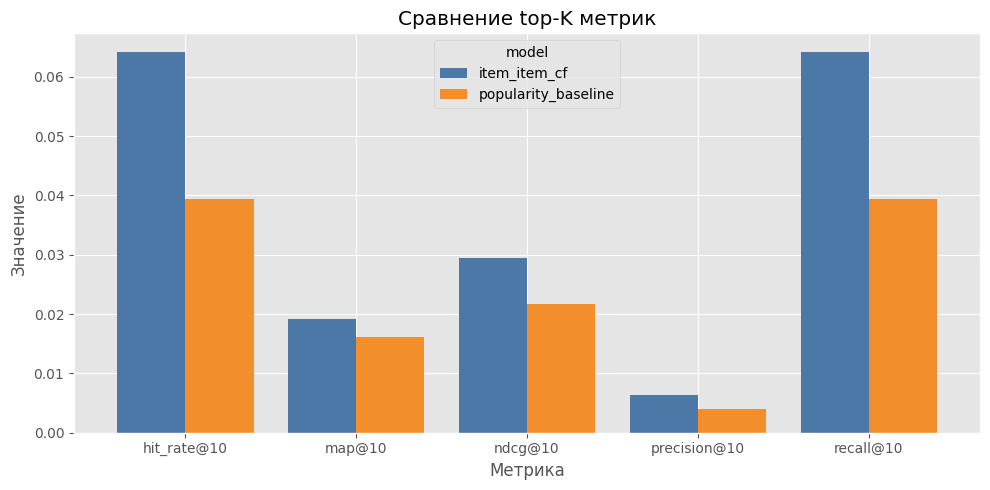

In [6]:
plot_df = comparison_df.melt(id_vars="model", var_name="metric", value_name="value")
plot_pivot = plot_df.pivot(index="metric", columns="model", values="value")

fig, ax = plt.subplots(figsize=(10, 5))
plot_pivot.plot(
    kind="bar",
    ax=ax,
    color=["#4C78A8", "#F28E2B"],
    width=0.8,
)

ax.set_title("Сравнение top-K метрик")
ax.set_xlabel("Метрика")
ax.set_ylabel("Значение")
ax.legend(title="model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Интерпретация результата

В этом запуске `item-based collaborative filtering` оказался лучше `popularity baseline` по всем основным top-K метрикам.

По `HitRate@10` и `Recall@10` модель выросла с `0.0395` до `0.0641`. В нашей постановке это особенно наглядно: у каждого пользователя в `test` только один релевантный объект, поэтому `Recall@10` и `HitRate@10` здесь совпадают.

По `Precision@10` рост тоже виден: `0.0039` против `0.0064`. Значение маленькое, и это нормально для рекомендательных систем на большом каталоге: даже хорошая модель редко делает top-10 список "плотно релевантным" в абсолютном смысле.

`MAP@10` и `NDCG@10` тоже выше у `item-based collaborative filtering` (`0.0191` и `0.0295` против `0.0162` и `0.0218`). Это значит, что collaborative filtering не только чаще находит релевантный объект, но и в среднем ставит его немного выше в списке.

Практический вывод здесь такой:

- `popularity baseline` остаётся важной точкой отсчёта;
- `item-based collaborative filtering` даёт устойчивый выигрыш сразу по нескольким метрикам, а не только по одной;
- смотреть только на `HitRate@10` недостаточно: `MAP@10` и `NDCG@10` показывают, насколько рано модель ставит полезный объект;
- маленькие абсолютные значения метрик не означают, что модель бесполезна: для sparse recommendation-задач важнее честное сравнение моделей между собой.


## Ограничения и аккуратность

При работе с метриками легко ошибиться даже в учебном проекте:

- нельзя считать их на train-взаимодействиях;
- нельзя смешивать candidate universe без объяснения;
- уже seen items должны быть отфильтрованы, если постановка этого требует;
- высокая offline-метрика не равна автоматически хорошему продукту;
- одна метрика почти никогда не описывает качество модели полностью.


## Что получилось

После этого notebook должно быть понятно:

- почему в recommender systems нужны специальные top-K метрики;
- как вручную проверить корректность формулы на tiny fixture;
- чем отличаются `Precision@K`, `Recall@K`, `HitRate@K`, `MAP@K`, `NDCG@K`;
- почему модель нужно сравнивать с baseline сразу по нескольким метрикам;
- как осторожно интерпретировать offline quality без лишних обещаний.

## Что дальше

Следующий шаг: [06_hybrid_intro.ipynb](/Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/notebooks/basic/06_hybrid_intro.ipynb). Там мы попробуем объединить несколько источников сигнала вместо выбора только одного подхода.
